# <!-- TITLE --> VAE, using a custom model class  (MNIST dataset)
<!-- DESC --> Construction and training of a VAE, using model subclass, with a latent space of small dimension.

## Objectives :
 - Understanding and implementing a **variational autoencoder** neurals network (VAE)
 - Understanding a still more **advanced programming model**, using a **custom model**

The calculation needs being important, it is preferable to use a very simple dataset such as MNIST to start with.  
...MNIST with a small scale if you haven't a GPU

## What we're going to do :

 - Defining a VAE model (as a subclass)
 - Build the model
 - Train it
 - Have a look on the train process

## Acknowledgements :
Thanks to **François Chollet** who is at the base of this example (and the creator of Keras !!).  
See : https://keras.io/examples/generative/vae


## Step 1 - Init python stuff

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers

import numpy as np

from modules.models    import VAE
from modules.layers    import SamplingLayer
from modules.callbacks import ImagesCallback
from modules.datagen   import MNIST


import matplotlib.pyplot as plt
import scipy.stats
import sys

import fidle

## Step 2 - Parameters
`scale` : with scale=1, we need 1'30s on a GPU V100 ...and >20' on a CPU !  
`latent_dim` : 2 dimensions is small, but usefull to draw !  
`fit_verbosity`: Verbosity of training progress bar: 0=silent, 1=progress bar, 2=One line  

`loss_weights` : Our **loss function** is the weighted sum of two loss:
 - `r_loss` which measures the loss during reconstruction.  
 - `kl_loss` which measures the dispersion.  

The weights are defined by: `loss_weights=[k1,k2]` where : `total_loss = k1*r_loss + k2*kl_loss`  
In practice, a value of \[1,.06\] gives good results here.


In [30]:
latent_dim    = 7 #2 if we want to visualize the latent space (harder compression though)
loss_weights  = [1,.06]

scale         = .4
seed          = 123

batch_size    = 64
epochs        = 4
fit_verbosity = 1

## Step 3 - Prepare data
`MNIST.get_data()` return : `x_train,y_train, x_test,y_test`,  \
but we only need x_train for our training.

Seeded (123)
Dataset loaded.
Concatenated.
Shuffled.
rescaled (0.4).
Normalized.
Reshaped.
splited (1).
x_train shape is  :  (28000, 28, 28, 1)
x_test  shape is  :  (0, 28, 28, 1)
y_train shape is  :  (28000,)
y_test  shape is  :  (0,)
Blake2b digest is :  364206373721ad69bb9c


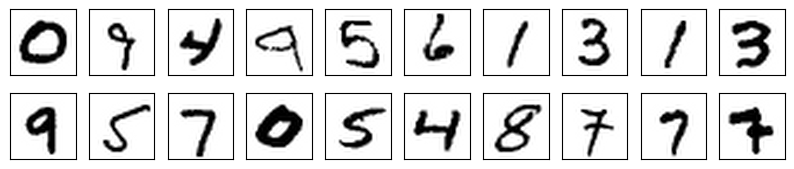

In [31]:
x_data, y_data, _,_ = MNIST.get_data(seed=seed, scale=scale, train_prop=1 )

fidle.scrawler.images(x_data[:20], None, indices='all', columns=10, x_size=1,y_size=1,y_padding=0, save_as='01-original')

## Step 4 - Build model
In this example, we will use a **custom model**.

<img width="800px" src="./img/model2.png"></img>

For this, we will use :
 - `SamplingLayer`, which generates a vector z from the parameters z_mean and z_log_var - See : [SamplingLayer.py](./modules/layers/SamplingLayer.py)
 - `VAE`, a custom model with a specific train_step - See : [VAE.py](./modules/models/VAE.py)

#### Encoder

In [32]:
inputs    = keras.Input(shape=(28, 28, 1))
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(16, activation="relu")(x)

z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z         = SamplingLayer()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.compile()

#### Decoder

In [33]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs)
x       = layers.Reshape((7, 7, 64))(x) # reshape ?
x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(inputs, outputs, name="decoder")
decoder.compile()

#### VAE
`VAE` is a custom model with a specific train_step - See : [VAE.py](./modules/models/VAE.py)

This is a lower-level implementation similar to `pytorch`. We subclass `keras.Model` and define:
- `__init__()` for model architecture
- `call()` for the forward pass
- a custom training loop including loss computation and gradient updates.

Gradients are computed by tracking all operations involved in the loss using `tensorflow`'s automatic differentiation (GradientTape). At the end of the forward pass, the tape is used to backpropagate and compute parameter updates.

In [34]:
vae = VAE(encoder, decoder, loss_weights)

vae.compile(optimizer='adam')

Fidle VAE is ready :-)  loss_weights=[1, 0.06]


## Step 5 - Train
### 5.1 - Using two nice custom callbacks :-)
Two custom callbacks are used:
 - `ImagesCallback` : qui va sauvegarder des images durant l'apprentissage - See [ImagesCallback.py](./modules/callbacks/ImagesCallback.py)
 - `BestModelCallback` : qui sauvegardera le meilleur model - See [BestModelCallback.py](./modules/callbacks/BestModelCallback.py)

In [35]:
run_dir = '.'

callback_images      = ImagesCallback(x=x_data, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]

### 5.2 - Let's train !
With `scale=1`, need 1'15 on a GPU (V100 at IDRIS) ...or 20' on a CPU  

In [36]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(x_data, epochs=epochs, batch_size=batch_size, callbacks=callbacks_list, verbose=fit_verbosity)

chrono.show()

Epoch 1/4


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step/step - loss: 15675.319
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - loss: 12038.2451
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step/step - loss: 8721.044
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 75s 172ms/step - loss: 8433.5605
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step/step - loss: 7761.469
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 68s 154ms/step - loss: 7659.1650
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step/step - loss: 7426.185
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 70s 159ms/step - loss: 7370.3809
Duration :  288.7 seconds


## Step 6 - Training review
### 6.1 - History

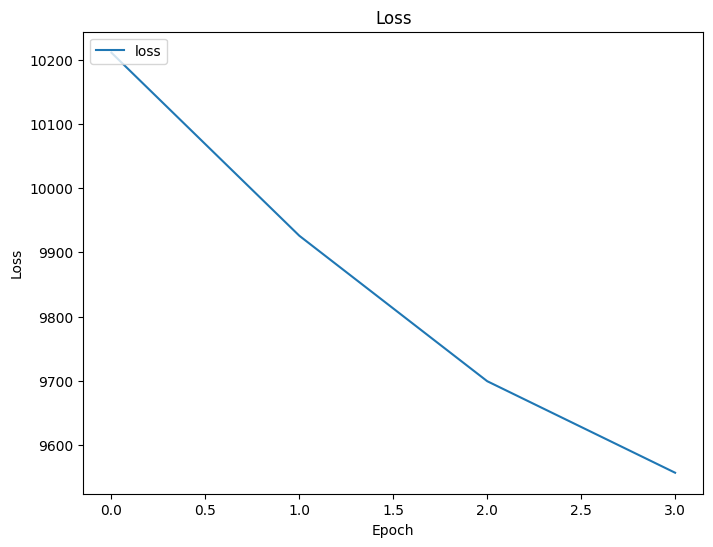

In [22]:
fidle.scrawler.history(history,  plot={"Loss":['loss']}, save_as='history')

### 6.2 - Reconstruction during training
At the end of each epoch, our callback saved some reconstructed images.  
Where :  
Original image -> encoder -> z -> decoder -> Reconstructed image

<br>**Original images :**

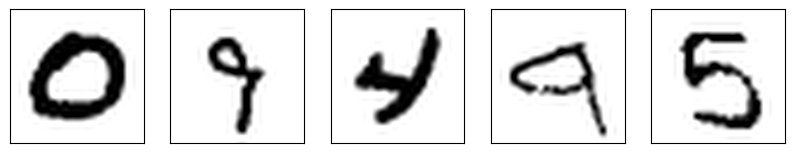

<br>**Encoded/decoded images**

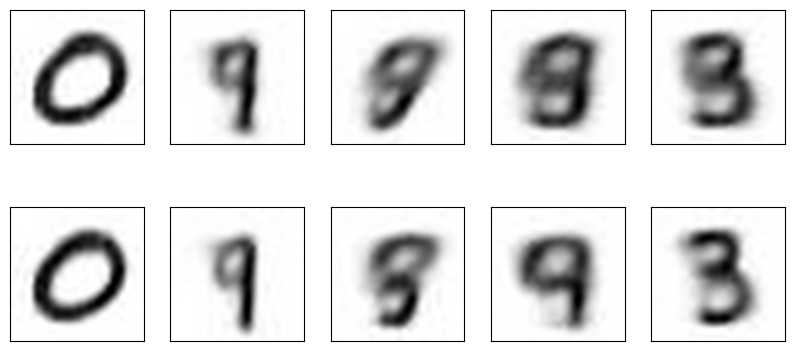

<br>**Original images :**

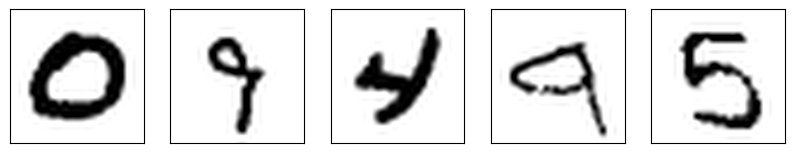

In [23]:
images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-original')

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-reconstruct')

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)


### 6.3 - Generation (latent -> decoder) during training

<br>**Generated images from latent space**

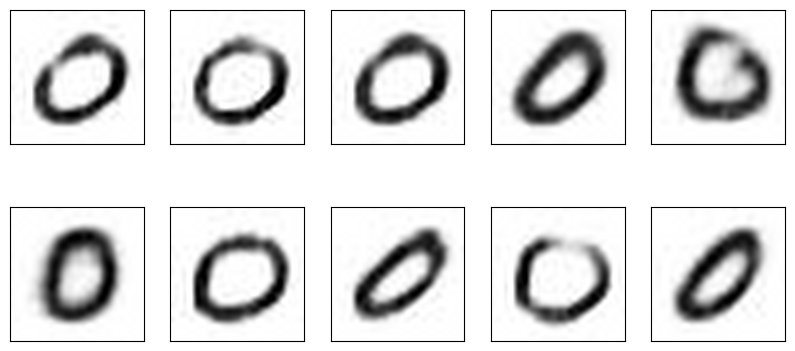

In [24]:
fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r, None, indices='all', columns=5, x_size=2,y_size=2, save_as='04-encoded')

### 6.4 - Save model

In [25]:
os.makedirs(f'{run_dir}/models', exist_ok=True)

vae.save(f'{run_dir}/models/vae_model.keras')

## Step 7 - Model evaluation

### 7.1 - Reload model

In [26]:
vae=VAE()
vae.reload(f'{run_dir}/models/vae_model.keras')

Fidle VAE is ready :-)  loss_weights=[1, 1]
Reloaded.


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 7.2 - Image reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


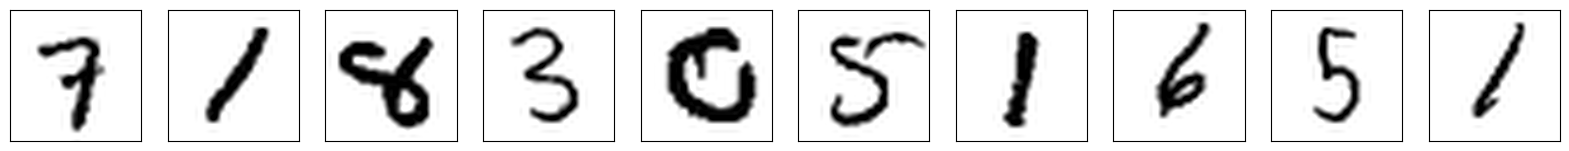

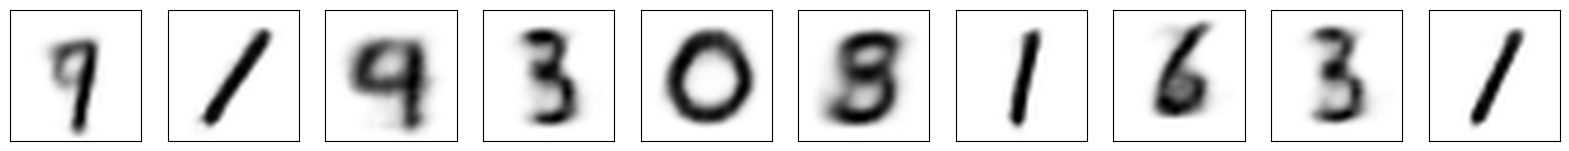

In [27]:
# ---- Select few images

x_show = fidle.utils.pick_dataset(x_data, n=10)

# ---- Get latent points and reconstructed images

z_mean, z_var, z  = vae.encoder.predict(x_show)
x_reconst         = vae.decoder.predict(z)

# ---- Show it

labels=[ str(np.round(z[i],1)) for i in range(10) ]
fidle.scrawler.images(x_show,    None, indices='all', columns=10, x_size=2,y_size=2, save_as='05-original')
fidle.scrawler.images(x_reconst, None, indices='all', columns=10, x_size=2,y_size=2, save_as='06-reconstruct')


### 7.3 - Visualization of the latent space

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


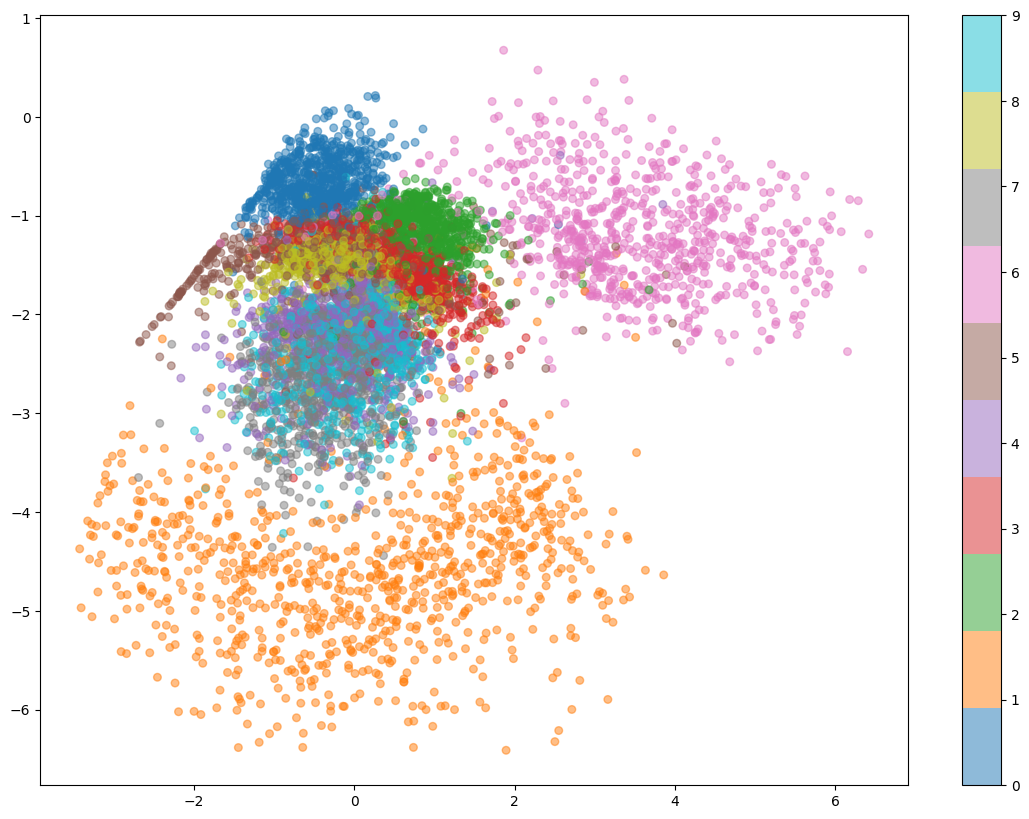

In [ ]:
#comment ça marche ?
n_show = int(20000*scale)


# ---- Select images

x_show, y_show = fidle.utils.pick_dataset(x_data,y_data, n=n_show)

# ---- Get latent points

z_mean, z_var, z = vae.encoder.predict(x_show)

# ---- Show them

fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 0] , z[:, 1], c=y_show, cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
fidle.scrawler.save_fig('07-Latent-space')
plt.show()

### 7.4 - Generative latent space

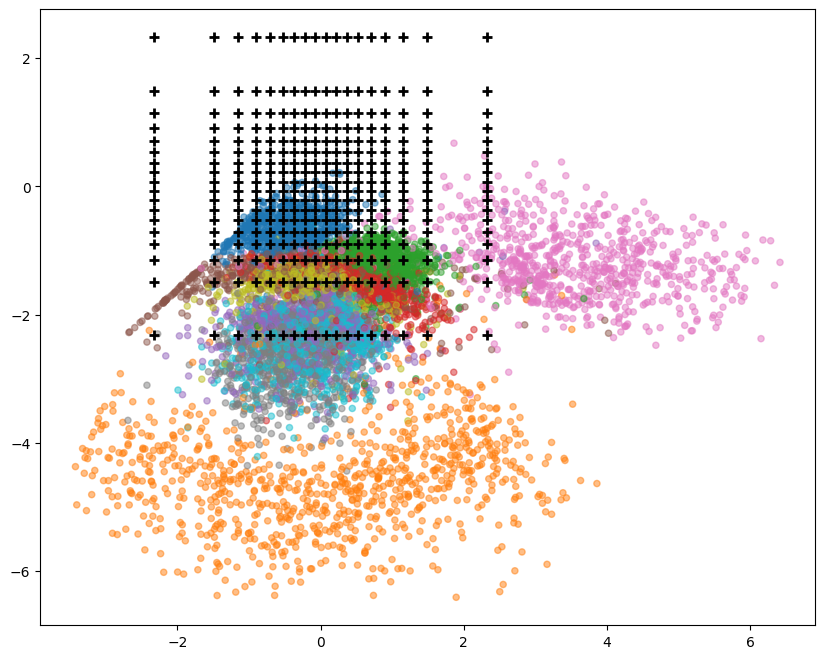

 4/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=torch.Size([32, 2]))']
  warnings.warn(msg)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=torch.Size([4, 2]))']
  warnings.warn(msg)


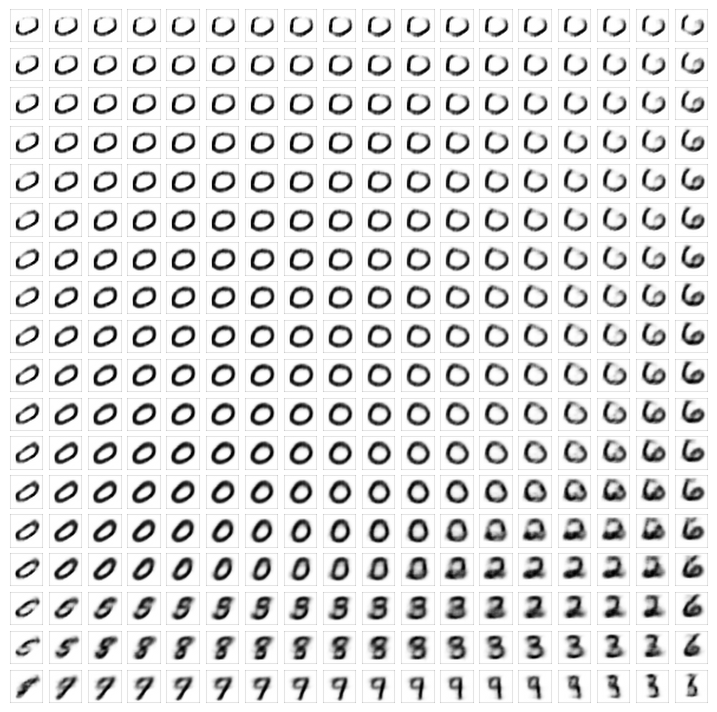

In [ ]:
if latent_dim>2:

    print('Sorry, This part can only work if the latent space is of dimension 2')

else:
    
    grid_size   = 18
    grid_scale  = 1

    # ---- Draw a ppf grid

    grid=[]
    for y in scipy.stats.norm.ppf(np.linspace(0.99, 0.01, grid_size),scale=grid_scale):
        for x in scipy.stats.norm.ppf(np.linspace(0.01, 0.99, grid_size),scale=grid_scale):
            grid.append( (x,y) )
    grid=np.array(grid)

    # ---- Draw latentspoints and grid

    fig = plt.figure(figsize=(10, 8))
    plt.scatter(z[:, 0] , z[:, 1], c=y_show, cmap= 'tab10', alpha=0.5, s=20)
    plt.scatter(grid[:, 0] , grid[:, 1], c = 'black', s=60, linewidth=2, marker='+', alpha=1)
    fidle.scrawler.save_fig('08-Latent-grid')
    plt.show()

    # ---- Plot grid corresponding images

    x_reconst = vae.decoder.predict([grid])
    fidle.scrawler.images(x_reconst, indices='all', columns=grid_size, x_size=0.5,y_size=0.5, y_padding=0,spines_alpha=0.1, save_as='09-Latent-morphing')

#comment ça marche ? qu'elle est l'objectif visuel ?
#à quoi serve le damier de petite croix ?


In [ ]:
import pandas as pd

# dataframe
df = pd.DataFrame(z, columns=[f'z{i}' for i in range(z.shape[1])])
df["label"] = y_show
#Visualiser comment les images MNIST se distribuent dans l'espace latent après encodage, colorées par leur chiffre (0-9).


sns.pairplot(df, hue="label", palette="tab10", plot_kws={'alpha':0.5, 's':20})
#on essaye de voir si les différentes classes (chiffres) sont regroupées ou mélangées dans l'espace latent, 
# et si certaines dimensions latentes sont plus discriminantes que d'autres pour séparer les classes.
plt.show()